# Предсказание риска сердечного приступа

Цель проекта — построить модель машинного обучения для предсказания риска сердечного приступа на основе медицинских данных пациентов.

В рамках данной работы будет выполнено:
- исследование данных (EDA)
- предобработка данных
- обучение моделей
- выбор лучшей модели
- подготовка предсказаний для тестовой выборки

In [1]:
#Импорт библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

e:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


### Загрузка данных

Загрузим обучающий и тестовый датасеты. 
Обучающий датасет содержит целевую переменную, а тестовый будет использоваться для финального предсказания.

In [2]:
train = pd.read_csv("E:\ProjectMonth\data\heart_train.csv")
test = pd.read_csv("E:\ProjectMonth\data\heart_test.csv")

Посмотрим на первые строки обучающего датасета, чтобы понять структуру данных и типы признаков.

In [3]:
pd.set_option('display.max_columns', None)
train.head()

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


Посмотрим количество строк и столбцов в обучающем и тестовом датасетах.

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8685, 28)
Test shape: (966, 27)


Изучим типы данных и наличие пропусков.

In [5]:
pd.set_option('display.max_columns', None)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

In [6]:
train.describe()

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Systolic blood pressure,Diastolic blood pressure,id
count,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000
mean,4342.000000,0.449958,0.501070,0.050658,0.652097,0.489576,0.902867,0.498342,0.601990,0.503378,1.057455,0.495380,0.501185,5.493367,0.499164,0.496055,0.496774,0.505484,3.508292,0.503737,0.346920,0.227339,0.048159,0.036689,0.450295,0.497634,4831.210823
std,2507.287877,0.231174,0.284716,0.023453,0.476333,0.499921,0.296157,0.500027,0.489517,0.284810,0.866645,0.500008,0.500028,2.867862,0.285340,0.284698,0.282561,0.286320,2.281772,0.328061,0.476017,0.076635,0.075531,0.060157,0.170184,0.171830,2782.585625
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2171.000000,0.258427,0.267857,0.034830,0.000000,0.000000,1.000000,0.000000,0.000000,0.263286,0.000000,0.000000,0.000000,3.000000,0.255875,0.251922,0.254190,0.263636,2.000000,0.166667,0.000000,0.227018,0.048229,0.036512,0.303226,0.348837,2425.000000
50%,4342.000000,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,0.000000,1.000000,0.502110,1.000000,0.000000,1.000000,5.000000,0.499920,0.494889,0.494774,0.503603,3.000000,0.500000,0.000000,0.227018,0.048229,0.036512,0.445161,0.500000,4837.000000
75%,6513.000000,0.640449,0.746429,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.748709,2.000000,1.000000,1.000000,8.000000,0.744623,0.741036,0.736974,0.750649,6.000000,0.833333,1.000000,0.227018,0.048229,0.036512,0.600000,0.651163,7242.000000
max,8684.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9650.000000


Определим количество пропусков в каждом признаке.

In [7]:
train.isnull().sum().sort_values(ascending=False)

Stress Level                       243
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Physical Activity Days Per Week    243
Previous Heart Problems            243
Medication Use                     243
Unnamed: 0                           0
Heart Attack Risk (Binary)           0
Blood sugar                          0
CK-MB                                0
Gender                               0
Troponin                             0
Systolic blood pressure              0
Diastolic blood pressure             0
Sleep Hours Per Day                  0
Sedentary Hours Per Day              0
Triglycerides                        0
BMI                                  0
Income                               0
Age                                  0
Diet                                 0
Exercise Hours Per Week              0
Heart rate               

In [8]:
# категориальные признаки
cat_cols = train.select_dtypes(include="category").columns

# числовые признаки
num_cols = train.select_dtypes(include=["float64", "int64"]).columns

Проверим, есть ли в данных полностью повторяющиеся строки.

In [9]:
train.duplicated().sum()

0

Разделим данные на признаки (X) и целевую переменную (y).

In [10]:
train.columns

Index(['Unnamed: 0', 'Age', 'Cholesterol', 'Heart rate', 'Diabetes',
       'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems',
       'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income',
       'BMI', 'Triglycerides', 'Physical Activity Days Per Week',
       'Sleep Hours Per Day', 'Heart Attack Risk (Binary)', 'Blood sugar',
       'CK-MB', 'Troponin', 'Gender', 'Systolic blood pressure',
       'Diastolic blood pressure', 'id'],
      dtype='object')

После первичного просмотра данных можно заметить несколько особенностей датасета:

1. Столбец Unnamed: 0 является лишним индексом и не несёт полезной информации.
2. Целевая переменная Heart Attack Risk (Binary) имеет слишком длинное название, поэтому для удобства переименуем её в target.
3. Столбец id является идентификатором наблюдения и не должен использоваться при обучении модели.
4. Признак Gender является категориальным и должен быть закодирован в числовой формат.

Выполним соответствующие преобразования.

In [11]:
# удаляем лишний индекс
train = train.drop(columns=["Unnamed: 0"])
test = test.drop(columns=["Unnamed: 0"])

# переименовываем target
train = train.rename(columns={"Heart Attack Risk (Binary)": "target"})

In [12]:
train["Gender"] = train["Gender"].map({
    "Male": 1,
    "Female": 0
})

test["Gender"] = test["Gender"].map({
    "Male": 1,
    "Female": 0
})

Перед обучением модели необходимо отделить целевую переменную от признаков.

Также удалим столбец `id`, так как он не содержит информации для обучения.

In [13]:
X = train.drop(columns=["target", "id"])
y = train["target"]

test_ids = test["id"]
test = test.drop(columns=["id"])

Некоторые признаки принимают ограниченное число значений (например 0/1 или несколько категорий), поэтому их можно считать категориальными.

In [14]:
categorical_cols = [
    "Diabetes",
    "Family History",
    "Smoking",
    "Obesity",
    "Alcohol Consumption",
    "Diet",
    "Previous Heart Problems",
    "Medication Use",
    "Gender"
]

In [15]:
for col in categorical_cols:
    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

В датасете присутствуют пропущенные значения в нескольких признаках.
Большинство из них являются категориальными признаками.

Для категориальных признаков пропуски заполним наиболее частым значением (модой).

Для числовых признаков пропуски заполним медианой.

In [16]:
# категориальные признаки
cat_cols = train.select_dtypes(include="category").columns

# числовые признаки
num_cols = train.select_dtypes(include=["float64", "int64"]).columns

# убираем target
num_cols = num_cols.drop(["target", "id"])

In [17]:
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(train[col].mode()[0])

In [18]:
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

In [19]:
train.isnull().sum().sort_values(ascending=False)

Age                                0
Income                             0
Diastolic blood pressure           0
Systolic blood pressure            0
Gender                             0
Troponin                           0
CK-MB                              0
Blood sugar                        0
target                             0
Sleep Hours Per Day                0
Physical Activity Days Per Week    0
Triglycerides                      0
BMI                                0
Sedentary Hours Per Day            0
Cholesterol                        0
Stress Level                       0
Medication Use                     0
Previous Heart Problems            0
Diet                               0
Exercise Hours Per Week            0
Alcohol Consumption                0
Obesity                            0
Smoking                            0
Family History                     0
Diabetes                           0
Heart rate                         0
id                                 0
d

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", test.shape)

X shape: (8685, 25)
y shape: (8685,)
Test shape: (966, 25)


### Анализ целевой переменной

Перед обучением модели важно проверить распределение целевой переменной.
Это позволяет понять, является ли задача сбалансированной или присутствует
дисбаланс классов.

In [21]:
train["target"].value_counts()

0.0    5672
1.0    3013
Name: target, dtype: int64

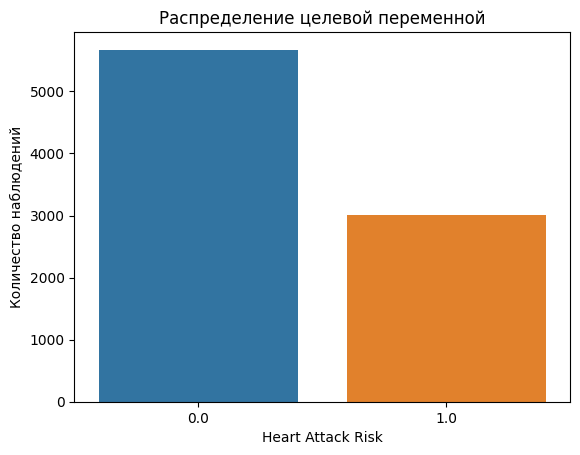

In [22]:
sns.countplot(x=train["target"])
plt.title("Распределение целевой переменной")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Количество наблюдений")
plt.show()

Целевая переменная распределена следующим образом:

- класс 0 (низкий риск): 5672 наблюдения
- класс 1 (высокий риск): 3013 наблюдений

Можно заметить умеренный дисбаланс классов. 
Однако он не является критическим, поэтому можно использовать стандартные методы обучения моделей.

При необходимости можно учитывать дисбаланс с помощью метрик, таких как F1-score.


Построим гистограммы для числовых признаков, чтобы изучить их распределение
и выявить возможные выбросы.

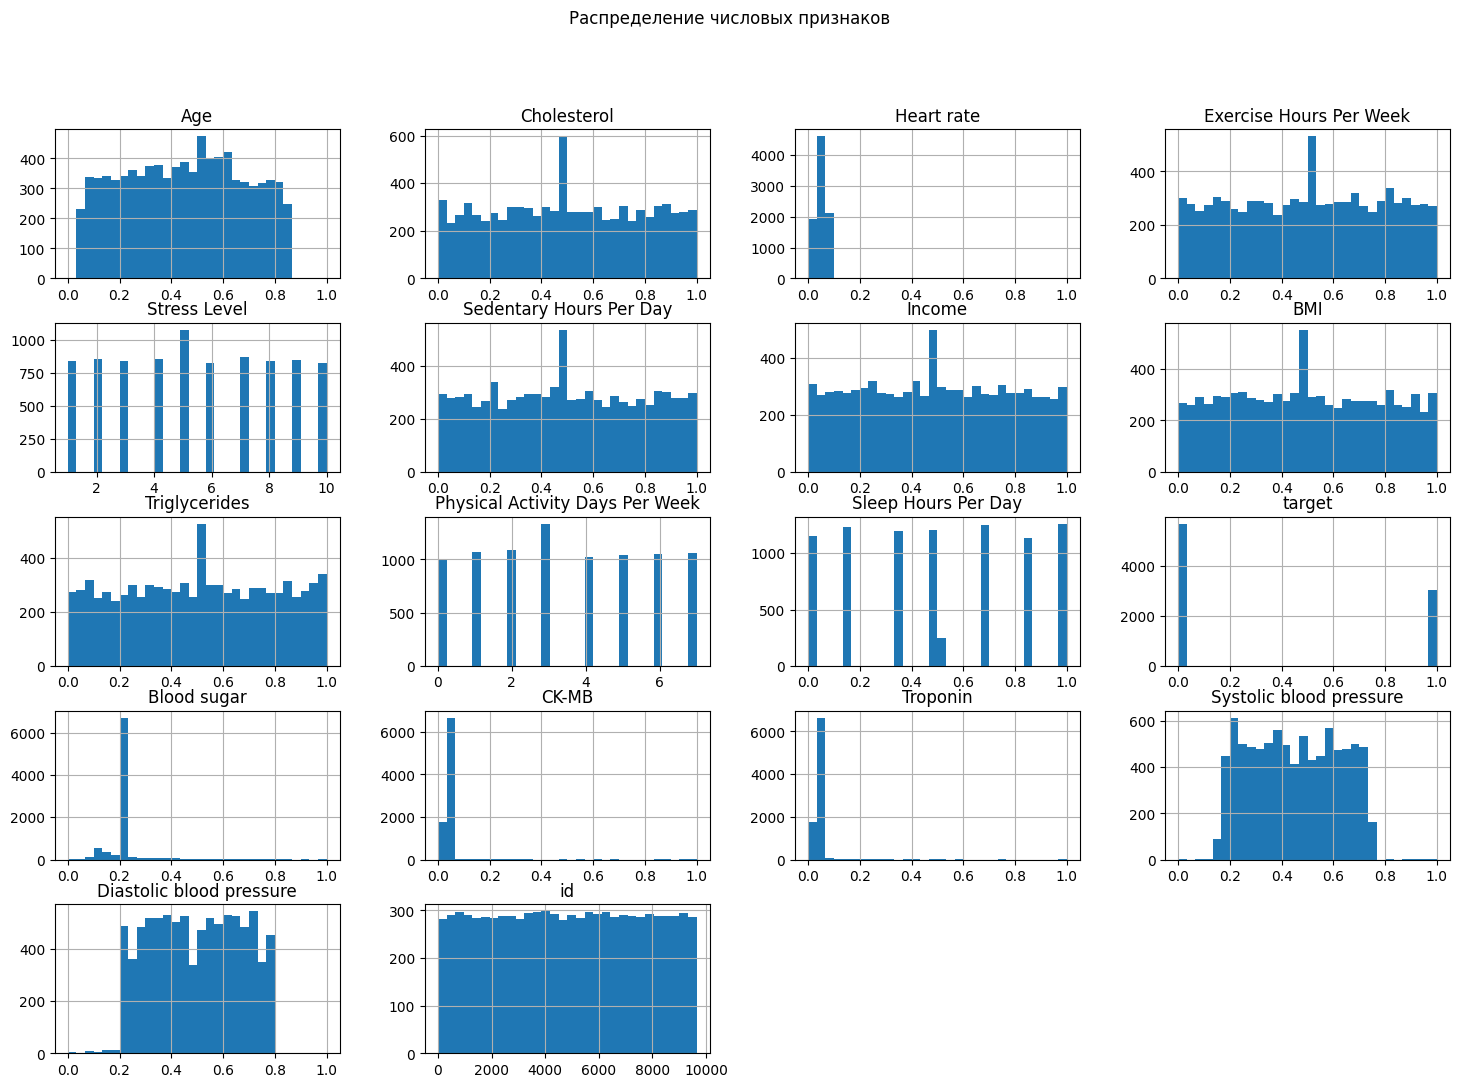

In [23]:
numeric_cols = train.select_dtypes(include=["float64", "int64"]).columns

train[numeric_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.suptitle("Распределение числовых признаков")
plt.show()

Анализ распределений числовых признаков показывает несколько особенностей датасета:

1. Большинство признаков уже масштабированы и принимают значения в диапазоне от 0 до 1.
2. Некоторые признаки имеют дискретное распределение (например, Physical Activity Days Per Week или Sleep Hours Per Day), что связано с их природой.
3. Биохимические показатели (Troponin, CK-MB, Blood sugar) имеют сильно скошенные распределения, что может быть связано с физиологическими особенностями этих показателей.
4. Визуально не наблюдается критических выбросов, что является положительным фактором для обучения моделей.

Таким образом, данные выглядят достаточно чистыми и подготовленными для дальнейшего анализа и обучения моделей машинного обучения.

Матрица корреляций позволяет выявить взаимосвязи между признаками,
а также определить признаки, которые могут быть наиболее связаны
с целевой переменной.

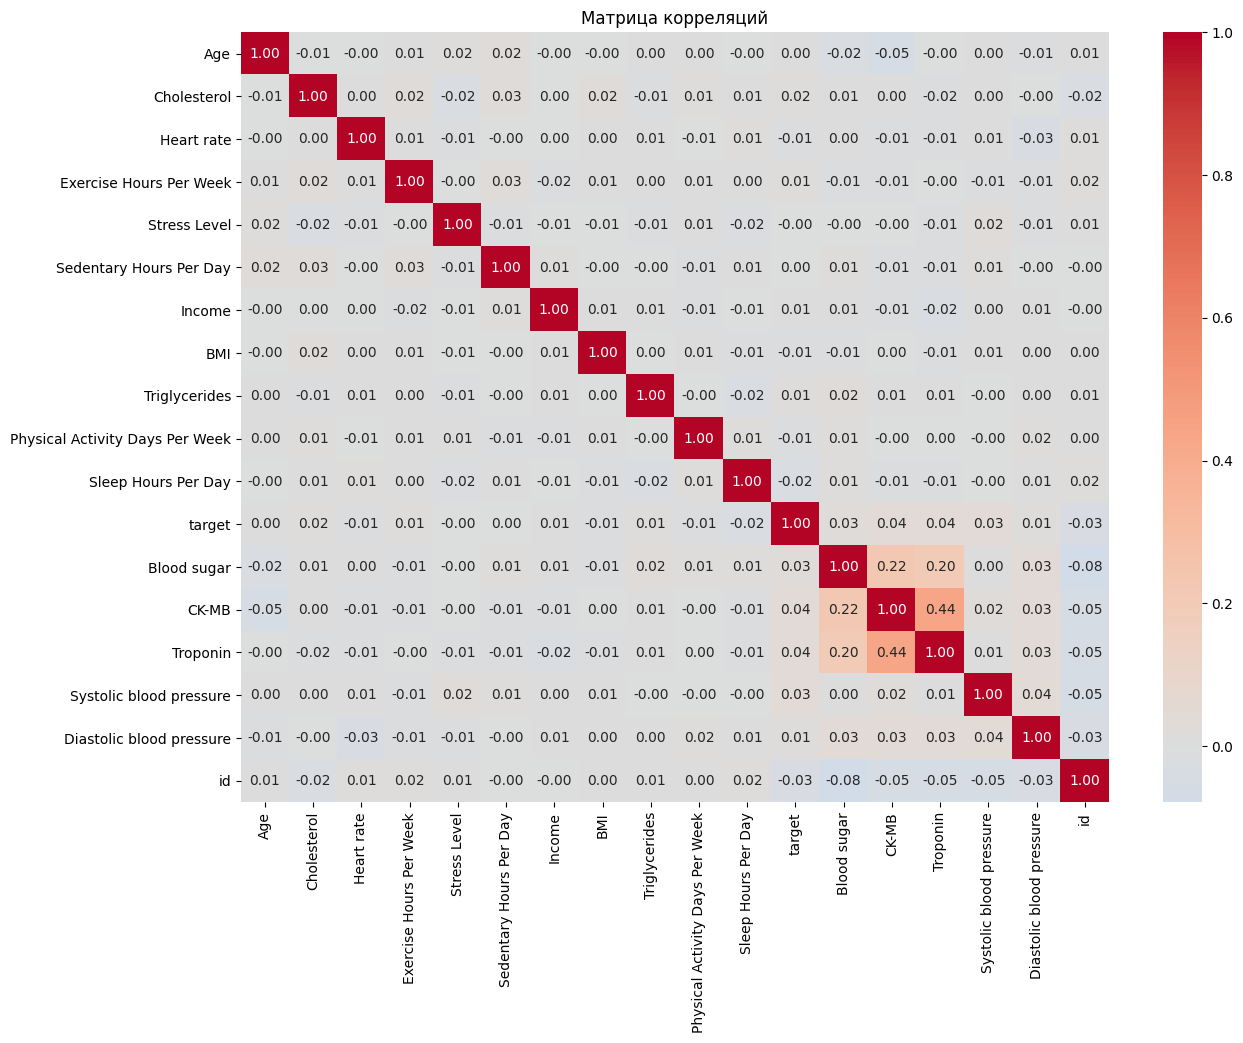

In [24]:


plt.figure(figsize=(14,10))

corr = train.corr(method="spearman")

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,      # показывает числа
    fmt=".2f"        # 2 знака после запятой
)

plt.title("Матрица корреляций")
plt.show()


Анализ корреляционной матрицы показывает следующие особенности:

1. Наиболее заметная корреляция наблюдается между признаками CK-M и Troponin (0.44). 
   Это ожидаемо, так как оба показателя являются биохимическими маркерами сердечных повреждений.

2. Умеренная положительная корреляция наблюдается между уровнем сахара в крови (Blood sugar) 
   и кардиомаркерами (CK-MB, Troponin), что может быть связано с влиянием диабета на сердечно-сосудистую систему.

3. В целом большинство признаков имеют низкую взаимную корреляцию, 
   что говорит об отсутствии сильной мультиколлинеарности в данных.

4. Линейная зависимость между признаками и целевой переменной target выражена слабо. 
   Это может указывать на наличие более сложных нелинейных зависимостей, 
   которые могут быть выявлены моделями машинного обучения.

In [25]:
train.corr(method="spearman")["target"].sort_values(ascending=False)

target                             1.000000
CK-MB                              0.038426
Troponin                           0.036082
Systolic blood pressure            0.034234
Blood sugar                        0.025114
Cholesterol                        0.018324
Triglycerides                      0.012108
Diastolic blood pressure           0.010641
Exercise Hours Per Week            0.010200
Income                             0.008537
Age                                0.004859
Sedentary Hours Per Day            0.001542
Stress Level                      -0.001909
BMI                               -0.007536
Physical Activity Days Per Week   -0.008112
Heart rate                        -0.010015
Sleep Hours Per Day               -0.023987
id                                -0.028177
Name: target, dtype: float64

Зависимость между признаками и риском
сердечного приступа носит нелинейный характер.

В связи с этим для решения задачи могут быть более эффективны
модели, способные выявлять сложные нелинейные зависимости,
например модели на основе деревьев решений или градиентного бустинга.

## Обучение моделей машинного обучения

На данном этапе будет выполнено обучение нескольких моделей машинного обучения.

Будут рассмотрены следующие модели:

- Logistic Regression
- Random Forest
- CatBoost

Для оценки качества моделей используется метрика **F1-score**, 
так как в задаче присутствует умеренный дисбаланс классов.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier

train / validation split

In [27]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
# переводим категориальные признаки в числа
cat_cols = train.select_dtypes(include="category").columns

train[cat_cols] = train[cat_cols].astype(int)
test[cat_cols] = test[cat_cols].astype(int)
X = train.drop(columns=["target","id"])
y = train["target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(X_train.shape, X_valid.shape)

(6513, 25) (2172, 25)


In [28]:
LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=0.5
)

RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=False,
    random_state=RANDOM_STATE,
    auto_class_weights="Balanced"
)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=500, learning_rate=0.05, random_state=42, verbose=False)

Pipeline для Logistic Regression

In [29]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

Pipeline Random Forest

In [30]:
cat_pipe = Pipeline([
    ("model", CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_state=RANDOM_STATE,
        auto_class_weights="Balanced"
    ))
])

Pipeline CatBoost

In [31]:
cat_pipe = Pipeline([
    ("model", CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_state=RANDOM_STATE
    ))
])

In [32]:
# обучаем финальную модель на всех данных

final_model = logreg_pipe

final_model.fit(X, y)

# лучший порог
best_threshold = 0.52

# получаем вероятности
test_probs = final_model.predict_proba(test)[:,1]

# применяем threshold
test_preds = (test_probs > best_threshold).astype(int)

# создаем submission
submission = pd.DataFrame({
    "id": test_ids,
    "prediction": test_preds
})

submission.to_csv(
    "../predictions/submission.csv",
    index=False
)

submission.head()

,id,prediction
0,7746,0
1,4202,1
2,6632,1
3,4639,1
4,4825,1


In [33]:
probs = logreg_pipe.predict_proba(X_valid)[:,1]

threshold = 0.35

preds = (probs > threshold).astype(int)

print(classification_report(y_valid, preds))

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    
    preds = (probs > t).astype(int)
    
    f1 = f1_score(y_valid, preds)
    
    print(f"threshold={t:.2f} - f1={f1:.3f}")

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00      1418
         1.0       0.35      1.00      0.52       754

    accuracy                           0.35      2172
   macro avg       0.67      0.50      0.26      2172
weighted avg       0.77      0.35      0.18      2172

threshold=0.10 - f1=0.515
threshold=0.15 - f1=0.515
threshold=0.20 - f1=0.515
threshold=0.25 - f1=0.515
threshold=0.30 - f1=0.515
threshold=0.35 - f1=0.516
threshold=0.40 - f1=0.518
threshold=0.45 - f1=0.515
threshold=0.50 - f1=0.427
threshold=0.55 - f1=0.214
threshold=0.60 - f1=0.013
threshold=0.65 - f1=0.000
threshold=0.70 - f1=0.000
threshold=0.75 - f1=0.000
threshold=0.80 - f1=0.000
threshold=0.85 - f1=0.000


Обучение моделей

In [34]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          966 non-null    int64
 1   prediction  966 non-null    int32
dtypes: int32(1), int64(1)
memory usage: 11.4 KB


In [35]:
submission["prediction"].value_counts()

0    645
1    321
Name: prediction, dtype: int64

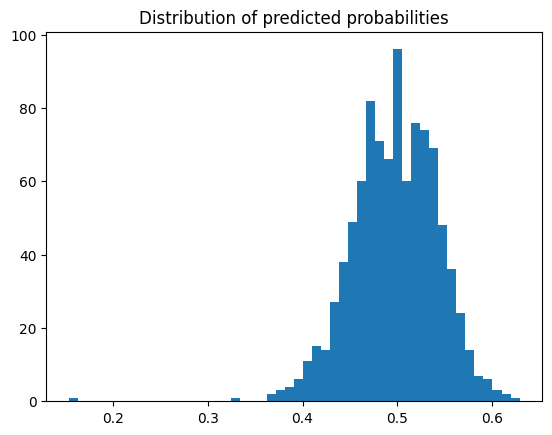

In [36]:
plt.hist(test_probs, bins=50)
plt.title("Distribution of predicted probabilities")
plt.show()

In [37]:
submission.to_csv("submission.csv", index=False)

In [38]:
submission.head()

,id,prediction
0,7746,0
1,4202,1
2,6632,1
3,4639,1
4,4825,1


In [39]:
import joblib

feature_names = X.columns.tolist()

joblib.dump(final_model, "../models/model.pkl")
joblib.dump(feature_names, "../models/features.pkl")

['../models/features.pkl']